--- Model Classes ---
{0: 'fire', 1: 'smoke'}
---------------------


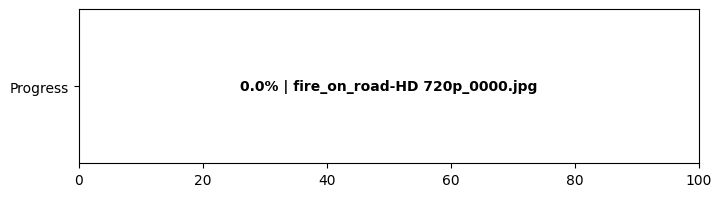

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import filedialog, messagebox
from ultralytics import YOLO

def select_preprocessed_root():
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)
    # 이미지들이 들어있는 최상위 폴더(예: 'images' 폴더 자체 혹은 그 부모)를 선택
    return filedialog.askdirectory(title="라벨링할 폴더 선택 (images 폴더가 포함된 곳)")

def run_auto_labeling_with_progress():
    ROOT_DIR = select_preprocessed_root()
    if not ROOT_DIR: return

    try:
        # device=0을 설정하여 NVIDIA GPU 가속 사용 (CPU만 있다면 제거하거나 'cpu'로 설정)
        model = YOLO("best_sb.pt") 
        print("--- Model Classes ---")
        print(model.names)
        print("---------------------")
    except Exception as e:
        messagebox.showerror("에러", f"모델 로드 실패: {e}")
        return

    img_extensions = ('.jpg', '.jpeg', '.png', '.bmp')
    all_tasks = []

    for root, dirs, files in os.walk(ROOT_DIR):
        # 이미 labels 폴더인 곳은 스킵
        if 'labels' in root: continue
        for file in files:
            if file.lower().endswith(img_extensions):
                all_tasks.append((root, file))
    
    total_count = len(all_tasks)
    if total_count == 0: 
        messagebox.showwarning("알림", "처리할 이미지 파일이 없습니다.")
        return

    plt.ion()
    fig, ax = plt.subplots(figsize=(8, 2))
    progress_bar = ax.barh(['Progress'], [0], color='#e74c3c')
    ax.set_xlim(0, 100)
    status_text = ax.text(50, 0, 'Processing...', ha='center', va='center', fontweight='bold')

    for i, (current_folder, img_name) in enumerate(all_tasks):
        try:
            # --- 경로 수정 핵심 부분 ---
            # current_folder가 '.../project/images' 라면
            # parent_dir은 '.../project'가 됩니다.
            parent_dir = os.path.dirname(current_folder)
            lbl_out_dir = os.path.join(parent_dir, "labels")
            os.makedirs(lbl_out_dir, exist_ok=True)

            img_path = os.path.join(current_folder, img_name)
            
            # 모델 추론 (GPU 사용을 위해 device=0 권장)
            img_data = cv2.imread(img_path)
            if img_data is None: continue

            # stream=True는 대량 이미지 처리 시 메모리 관리에 효율적입니다.
            results = model.predict(img_data, conf=0.15, imgsz=640, verbose=False, device=0)

            label_name = os.path.splitext(img_name)[0] + ".txt"
            label_path = os.path.join(lbl_out_dir, label_name)

            with open(label_path, 'w') as f:
                for r in results:
                    for box in r.boxes:
                        cls_id = int(box.cls[0])
                        cls_name = model.names[cls_id].lower()

                        target_id = -1
                        if 'fire' in cls_name: target_id = 0
                        elif 'smoke' in cls_name: target_id = 1
                        
                        if target_id != -1:
                            xywhn = box.xywhn[0].tolist()
                            f.write(f"{target_id} {xywhn[0]:.6f} {xywhn[1]:.6f} {xywhn[2]:.6f} {xywhn[3]:.6f}\n")

            if i % 5 == 0 or i == total_count - 1:
                percent = ((i + 1) / total_count) * 100
                progress_bar[0].set_width(percent)
                status_text.set_text(f"{percent:.1f}% | {img_name}")
                plt.pause(0.001)

        except KeyboardInterrupt:
            if messagebox.askyesno("중단", "작업을 중단하시겠습니까?"):
                break
        except Exception as e:
            print(f"파일 처리 중 오류 발생 ({img_name}): {e}")
            continue

    plt.ioff()
    messagebox.showinfo("완료", "라벨링 공정이 완료되었습니다.")
    plt.close()

if __name__ == "__main__":
    run_auto_labeling_with_progress()